# Monte Carlo vs Black-Scholes vs Delta Replication

1. Price a European call with the Black-Scholes closed form (reference).
2. Price it by Monte Carlo simulation of GBM terminal prices.
3. Price it by discrete delta hedging: the replication cost is the initial capital needed so that the self-financing hedge portfolio pays the option payoff.
4. Compare all three with ratios to Black-Scholes.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

## Parameters

In [2]:
S0 = 100.0     # spot
K = 100.0      # strike
T = 1.0        # maturity (years)
r = 0.03       # risk-free rate
sigma = 0.20   # volatility

n_paths = 100_000   # MC paths
n_steps = 252       # hedge rebalancing steps (daily)
seed = 42

## Black-Scholes

In [3]:
def bs_call(S, K, T, r, sigma):
    S = np.asarray(S, dtype=float)
    T = np.maximum(T, 1e-12)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)


def bs_call_delta(S, K, T, r, sigma):
    S = np.asarray(S, dtype=float)
    T = np.maximum(T, 1e-12)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return norm.cdf(d1)


bs_price = float(bs_call(S0, K, T, r, sigma))
print(f"Black-Scholes price: {bs_price:.4f}")

Black-Scholes price: 9.4134


## Monte Carlo

Under the risk-neutral measure $S_T = S_0 \exp\left((r - \tfrac{1}{2}\sigma^2)T + \sigma\sqrt{T}Z\right)$ and the price is $e^{-rT}\,\mathbb{E}[(S_T - K)^+]$.

In [4]:
rng = np.random.default_rng(seed)
Z = rng.standard_normal(n_paths)
ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
disc_payoff = np.exp(-r * T) * np.maximum(ST - K, 0.0)

mc_price = disc_payoff.mean()
mc_se = disc_payoff.std(ddof=1) / np.sqrt(n_paths)
print(f"Monte Carlo price:   {mc_price:.4f} ± {1.96 * mc_se:.4f} (95% CI)")
print(f"Black-Scholes price: {bs_price:.4f}")

Monte Carlo price:   9.3875 ± 0.0879 (95% CI)
Black-Scholes price: 9.4134


### Convergence with number of paths

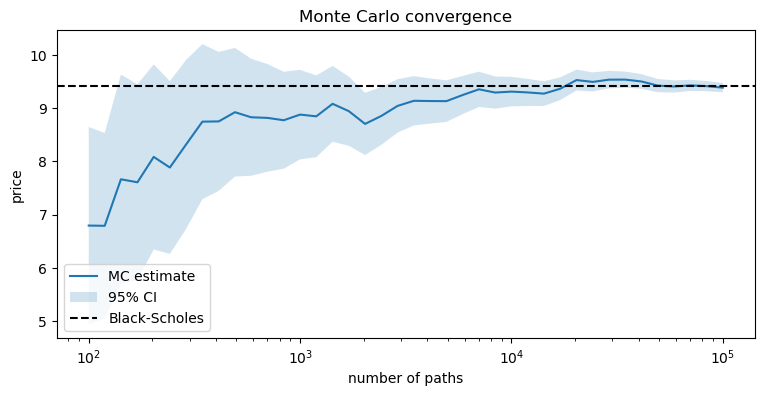

In [5]:
n_grid = np.unique(np.logspace(2, np.log10(n_paths), 40).astype(int))
running_mean = np.cumsum(disc_payoff) / np.arange(1, n_paths + 1)
running_se = np.array([disc_payoff[:n].std(ddof=1) / np.sqrt(n) for n in n_grid])

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(n_grid, running_mean[n_grid - 1], label="MC estimate")
ax.fill_between(n_grid, running_mean[n_grid - 1] - 1.96 * running_se,
                running_mean[n_grid - 1] + 1.96 * running_se, alpha=0.2, label="95% CI")
ax.axhline(bs_price, color="k", ls="--", label="Black-Scholes")
ax.set_xscale("log")
ax.set_xlabel("number of paths")
ax.set_ylabel("price")
ax.set_title("Monte Carlo convergence")
ax.legend()
plt.show()

## Delta hedging (replication)

Simulate full GBM paths and rebalance a BS delta hedge at each step. With discounted prices $\tilde S_t = e^{-rt}S_t$, a self-financing portfolio starting with capital $V_0$ and holding $\Delta_{t_i}$ shares satisfies

$$e^{-rT}V_T = V_0 + \sum_i \Delta_{t_i}\,(\tilde S_{t_{i+1}} - \tilde S_{t_i}).$$

Requiring $V_T = (S_T - K)^+$ gives the per-path replication cost

$$V_0^{\text{path}} = e^{-rT}(S_T - K)^+ - \sum_i \Delta_{t_i}\,(\tilde S_{t_{i+1}} - \tilde S_{t_i}).$$

Its average is the replication price; its dispersion is the hedging error from discrete rebalancing (it vanishes as $dt \to 0$).

In [6]:
def simulate_paths(S0, r, sigma, T, n_steps, n_paths, rng):
    dt = T / n_steps
    Z = rng.standard_normal((n_paths, n_steps))
    log_inc = (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z
    log_S = np.concatenate([np.zeros((n_paths, 1)), np.cumsum(log_inc, axis=1)], axis=1)
    return S0 * np.exp(log_S)


def delta_replication(paths, K, T, r, sigma):
    n_paths, n_cols = paths.shape
    n_steps = n_cols - 1
    t = np.linspace(0.0, T, n_steps + 1)
    disc_S = paths * np.exp(-r * t)

    deltas = bs_call_delta(paths[:, :-1], K, T - t[:-1], r, sigma)
    hedge_gain = np.sum(deltas * np.diff(disc_S, axis=1), axis=1)

    disc_payoff = np.exp(-r * T) * np.maximum(paths[:, -1] - K, 0.0)
    return disc_payoff - hedge_gain  # replication cost per path


rng = np.random.default_rng(seed)
paths = simulate_paths(S0, r, sigma, T, n_steps, n_paths, rng)
rep_cost = delta_replication(paths, K, T, r, sigma)

rep_price = rep_cost.mean()
rep_se = rep_cost.std(ddof=1) / np.sqrt(n_paths)
print(f"Delta replication price: {rep_price:.4f} ± {1.96 * rep_se:.4f} (95% CI)")
print(f"Per-path hedging error std: {rep_cost.std():.4f}")
print(f"Black-Scholes price:     {bs_price:.4f}")

Delta replication price: 9.4108 ± 0.0026 (95% CI)
Per-path hedging error std: 0.4247
Black-Scholes price:     9.4134


### Distribution: MC discounted payoff vs replication cost

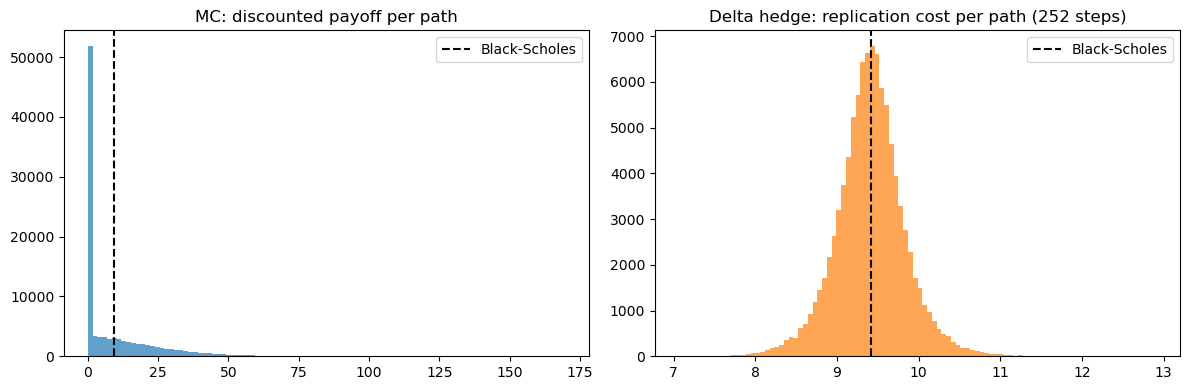

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(disc_payoff, bins=100, alpha=0.7)
axes[0].axvline(bs_price, color="k", ls="--", label="Black-Scholes")
axes[0].set_title("MC: discounted payoff per path")
axes[0].legend()

axes[1].hist(rep_cost, bins=100, alpha=0.7, color="tab:orange")
axes[1].axvline(bs_price, color="k", ls="--", label="Black-Scholes")
axes[1].set_title(f"Delta hedge: replication cost per path ({n_steps} steps)")
axes[1].legend()
plt.tight_layout()
plt.show()

### Hedging error vs rebalancing frequency

,replication_price,hedge_error_std,ratio_to_BS
n_steps,,,
4,9.4523,3.1575,1.0041
12,9.4182,1.8936,1.0005
52,9.4141,0.9295,1.0001
252,9.4113,0.4218,0.9998
1000,9.4119,0.2141,0.9998


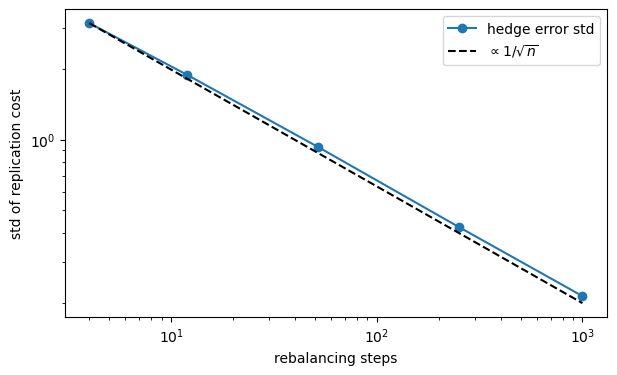

In [8]:
steps_grid = [4, 12, 52, 252, 1000]
rows = []
for n in steps_grid:
    rng_n = np.random.default_rng(seed)
    cost = delta_replication(simulate_paths(S0, r, sigma, T, n, 20_000, rng_n), K, T, r, sigma)
    rows.append({"n_steps": n, "replication_price": cost.mean(), "hedge_error_std": cost.std()})
freq = pd.DataFrame(rows).set_index("n_steps")
freq["ratio_to_BS"] = freq["replication_price"] / bs_price
display(freq.round(4))

fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(freq.index, freq["hedge_error_std"], "o-", label="hedge error std")
ax.loglog(freq.index, freq["hedge_error_std"].iloc[0] * np.sqrt(freq.index[0] / freq.index), "k--",
          label=r"$\propto 1/\sqrt{n}$")
ax.set_xlabel("rebalancing steps")
ax.set_ylabel("std of replication cost")
ax.legend()
plt.show()

## Comparison (Black-Scholes = reference)

In [9]:
summary = pd.DataFrame(
    {
        "price": [bs_price, mc_price, rep_price],
        "std_error": [0.0, mc_se, rep_se],
    },
    index=["Black-Scholes", "Monte Carlo", "Delta replication"],
)
summary["diff_vs_BS"] = summary["price"] - bs_price
summary["ratio_vs_BS"] = summary["price"] / bs_price
display(summary.round(4))

,price,std_error,diff_vs_BS,ratio_vs_BS
Black-Scholes,9.4134,0.0000,0.0000,1.0000
Monte Carlo,9.3875,0.0449,-0.0259,0.9972
Delta replication,9.4108,0.0013,-0.0026,0.9997


### Across strikes

,BS,MC,MC_se,Replication,MC/BS,Replication/BS
strike,,,,,,
70,32.2352,32.2720,0.0632,32.2350,1.0011,1.0000
75,27.6226,27.6601,0.0621,27.6221,1.0014,1.0000
80,23.2240,23.2614,0.0602,23.2237,1.0016,1.0000
85,19.1313,19.1687,0.0575,19.1307,1.0020,1.0000
90,15.4292,15.4664,0.0539,15.4285,1.0024,1.0000
95,12.1797,12.2130,0.0497,12.1790,1.0027,0.9999
100,9.4134,9.4443,0.0450,9.4108,1.0033,0.9997
105,7.1281,7.1558,0.0400,7.1240,1.0039,0.9994
110,5.2934,5.3245,0.0350,5.2916,1.0059,0.9997


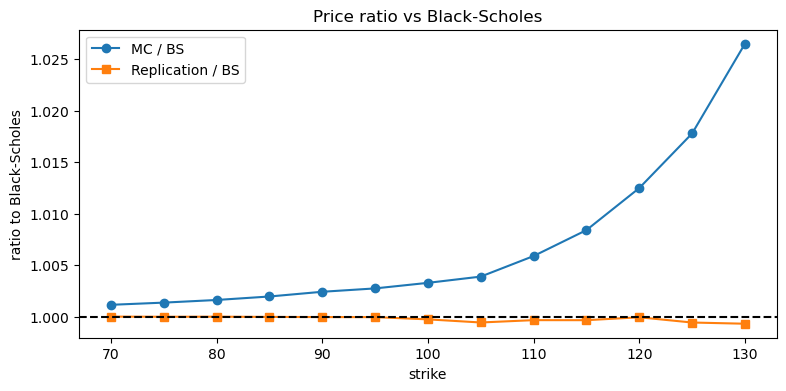

In [10]:
strikes = np.arange(70, 135, 5)
paths_k = paths  # reuse the simulated paths (same paths for every strike)
ST_k = paths_k[:, -1]

rows = []
for k in strikes:
    bs = float(bs_call(S0, k, T, r, sigma))
    pay = np.exp(-r * T) * np.maximum(ST_k - k, 0.0)
    rep = delta_replication(paths_k, k, T, r, sigma).mean()
    rows.append({"strike": k, "BS": bs, "MC": pay.mean(), "MC_se": pay.std(ddof=1) / np.sqrt(len(pay)),
                 "Replication": rep, "MC/BS": pay.mean() / bs, "Replication/BS": rep / bs})
by_strike = pd.DataFrame(rows).set_index("strike")
display(by_strike.round(4))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(by_strike.index, by_strike["MC/BS"], "o-", label="MC / BS")
ax.plot(by_strike.index, by_strike["Replication/BS"], "s-", label="Replication / BS")
ax.axhline(1.0, color="k", ls="--")
ax.set_xlabel("strike")
ax.set_ylabel("ratio to Black-Scholes")
ax.set_title("Price ratio vs Black-Scholes")
ax.legend()
plt.show()

**Takeaways**
- Monte Carlo converges to Black-Scholes at rate $1/\sqrt{N}$; the ratio is ~1 within the confidence interval. Out-of-the-money ratios are noisier because few paths finish in the money.
- Delta replication also recovers the Black-Scholes price on average, with a much tighter dispersion than the raw MC payoff: the hedge removes most of the path randomness (it acts as a control variate).
- The remaining replication error comes from discrete rebalancing and shrinks roughly like $1/\sqrt{n_{steps}}$.